In [1]:
# Install (run once)
!pip install -q nbeats-pytorch pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 18.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-iam 2.21.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.0 which is incompatible.
tensorflow-metadata 1.17.3 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.0 which is incompatible.
google-cloud-spanner 3.63.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.0 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 3.20.0 which is incompatible.
google-cloud-speech 2.37.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but 

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import optim
from torch.nn import functional as F
from nbeats_pytorch.model import NBeatsNet
from IPython.display import clear_output

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


from google.colab import drive
drive.mount('/content/drive')
!pwd

Mounted at /content/drive
/content


# NBEATS

In [3]:
# ============================================================================
# CONFIGURATION - CHANGE THESE
# ============================================================================
CSV_PATH = '/content/drive/MyDrive/2026 Winter STAD68/Project/Data/exchange_rate/exchange_rate.csv'
COLUMN_NAME = 'OT'  # Change to '1', '2', '3', '4', '5', '6', 'OT'
EPOCHS = 300
BATCH_SIZE = 128
FORECAST_HORIZON = 96
LOOKBACK_PERIOD = 10 * FORECAST_HORIZON  # 10 * FORECAST_HORIZON

# ============================================================================
# LOAD AND PREPARE DATA
# ============================================================================
print("Loading data...")
df = pd.read_csv(CSV_PATH)
data = df[COLUMN_NAME].values
dates = pd.to_datetime(df['date'])

print(f"✓ Loaded {len(data)} data points")
print(f"✓ Date range: {df['date'].iloc[0]} to {df['date'].iloc[-1]}")

# Normalize
norm_constant = np.max(data)
data_normalized = data / norm_constant

# Create sequences
X, y = [], []
for i in range(LOOKBACK_PERIOD, len(data_normalized) - FORECAST_HORIZON):
    X.append(data_normalized[i - LOOKBACK_PERIOD:i])
    y.append(data_normalized[i:i + FORECAST_HORIZON])

X = np.array(X)
y = np.array(y)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Get test dates
test_start_idx = LOOKBACK_PERIOD + split
test_dates = dates[test_start_idx:test_start_idx + len(X_test)]

print(f"✓ Train: {len(X_train)}, Test: {len(X_test)}")
print(f"✓ Test period: {test_dates.iloc[0].date()} to {test_dates.iloc[-1].date()}")

# ============================================================================
# CREATE AND TRAIN MODEL
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

model = NBeatsNet(
    device=device,
    backcast_length=LOOKBACK_PERIOD,
    forecast_length=FORECAST_HORIZON,
    stack_types=(NBeatsNet.GENERIC_BLOCK, NBeatsNet.GENERIC_BLOCK),
    nb_blocks_per_stack=2,
    thetas_dim=(4, 4),
    share_weights_in_stack=True,
    hidden_layer_units=128
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

# Training
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses, val_losses = [], []

print(f"\n{'='*80}")
print("TRAINING")
print(f"{'='*80}")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    n_batches = 0

    for i in range(0, len(X_train), BATCH_SIZE):
        batch_x = X_train_t[i:i+BATCH_SIZE]
        batch_y = y_train_t[i:i+BATCH_SIZE]

        optimizer.zero_grad()
        _, forecast = model(batch_x)
        loss = F.l1_loss(forecast, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches
    train_losses.append(train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        _, forecast = model(X_test_t)
        val_loss = F.l1_loss(forecast, y_test_t).item()
        val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

# ============================================================================
# PREDICTIONS AND METRICS
# ============================================================================
model.eval()
with torch.no_grad():
    _, predictions = model(X_test_t)
    predictions = predictions.cpu().numpy()

# Denormalize
y_test_actual = y_test * norm_constant
predictions_actual = predictions * norm_constant

# Metrics for each forecast step
metrics_per_step = {}
for step in range(FORECAST_HORIZON):
    step_actual = y_test_actual[:, step]
    step_pred = predictions_actual[:, step]

    metrics_per_step[f't+{step+1}'] = {
        'MSE': np.mean((step_actual - step_pred) ** 2),
        'MAE': np.mean(np.abs(step_actual - step_pred)),
        'MAPE': np.mean(np.abs((step_actual - step_pred) / (step_actual + 1e-8))) * 100
    }

# Overall metrics (averaged across all steps)
mse = np.mean((y_test_actual - predictions_actual) ** 2)
mae = np.mean(np.abs(y_test_actual - predictions_actual))
mape = np.mean(np.abs((y_test_actual - predictions_actual) / (y_test_actual + 1e-8))) * 100

print(f"\n{'='*80}")
print(f"RESULTS - Exchange Rate Column '{COLUMN_NAME}'")
print(f"{'='*80}")
print(f"Overall MSE:  {mse:.6f}")
print(f"Overall MAE:  {mae:.6f}")
print(f"Overall MAPE: {mape:.2f}%")
print(f"\n1-step ahead (t+1):")
print(f"  MSE:  {metrics_per_step['t+1']['MSE']:.6f}")
print(f"  MAE:  {metrics_per_step['t+1']['MAE']:.6f}")
print(f"  MAPE: {metrics_per_step['t+1']['MAPE']:.2f}%")
print(f"{'='*80}")



Loading data...
✓ Loaded 7588 data points
✓ Date range: 1990/1/1 0:00 to 2010/10/10 0:00
✓ Train: 5225, Test: 1307
✓ Test period: 2006-12-08 to 2010-07-06
✓ Using device: cuda
| N-Beats
| --  Stack Generic (#0) (share_weights_in_stack=True)
     | -- GenericBlock(units=128, thetas_dim=4, backcast_length=960, forecast_length=96, share_thetas=False) at @135726707817120
     | -- GenericBlock(units=128, thetas_dim=4, backcast_length=960, forecast_length=96, share_thetas=False) at @135726707817120
| --  Stack Generic (#1) (share_weights_in_stack=True)
     | -- GenericBlock(units=128, thetas_dim=4, backcast_length=960, forecast_length=96, share_thetas=False) at @135726710222832
     | -- GenericBlock(units=128, thetas_dim=4, backcast_length=960, forecast_length=96, share_thetas=False) at @135726710222832

TRAINING
Epoch  20/300 | Train: 0.134497 | Val: 0.093805
Epoch  40/300 | Train: 0.119266 | Val: 0.114120
Epoch  60/300 | Train: 0.115501 | Val: 0.089312
Epoch  80/300 | Train: 0.122896 | 


📊 Generating comprehensive visualizations...


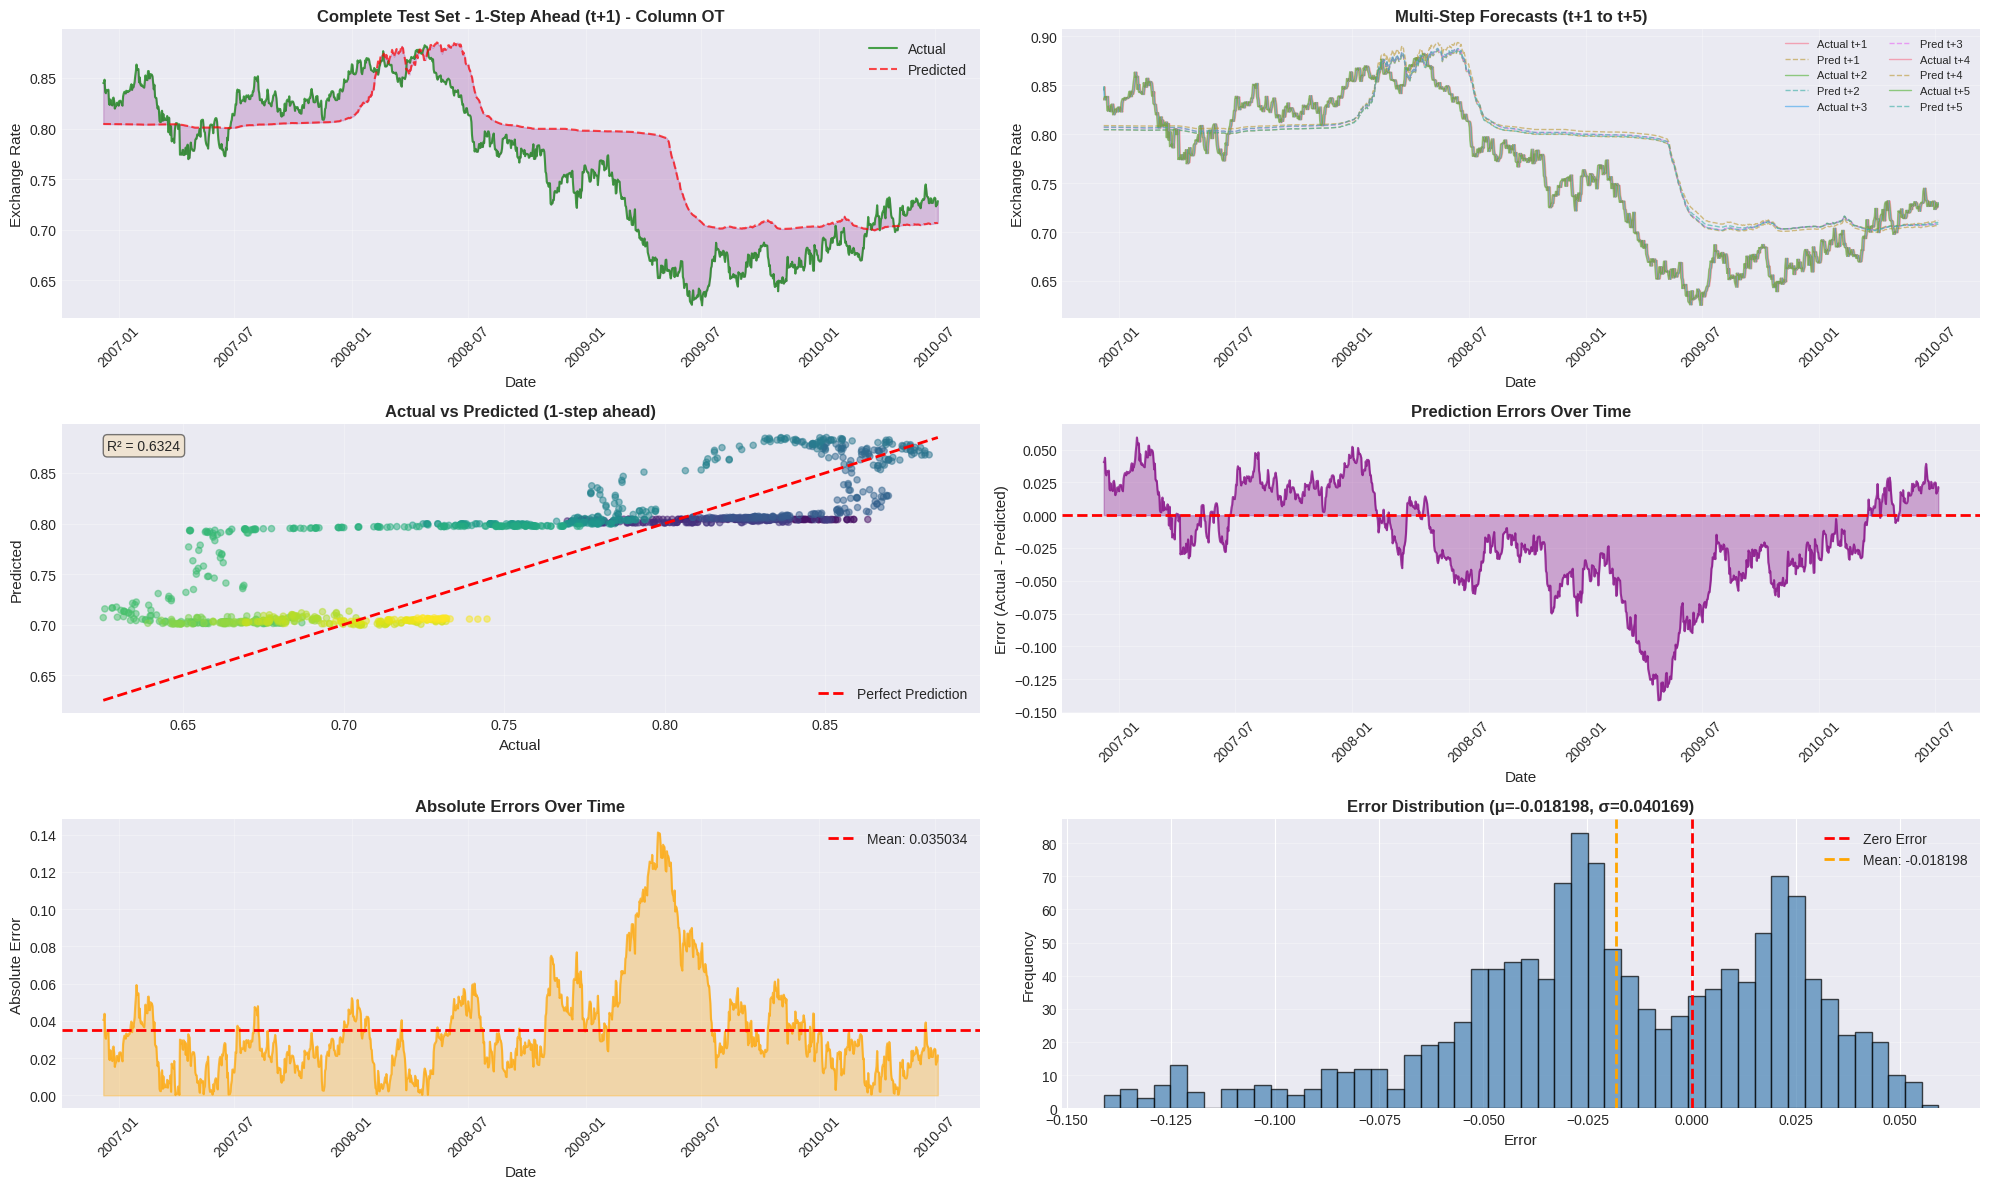

✓ Saved: full_test_analysis_column_OT.png


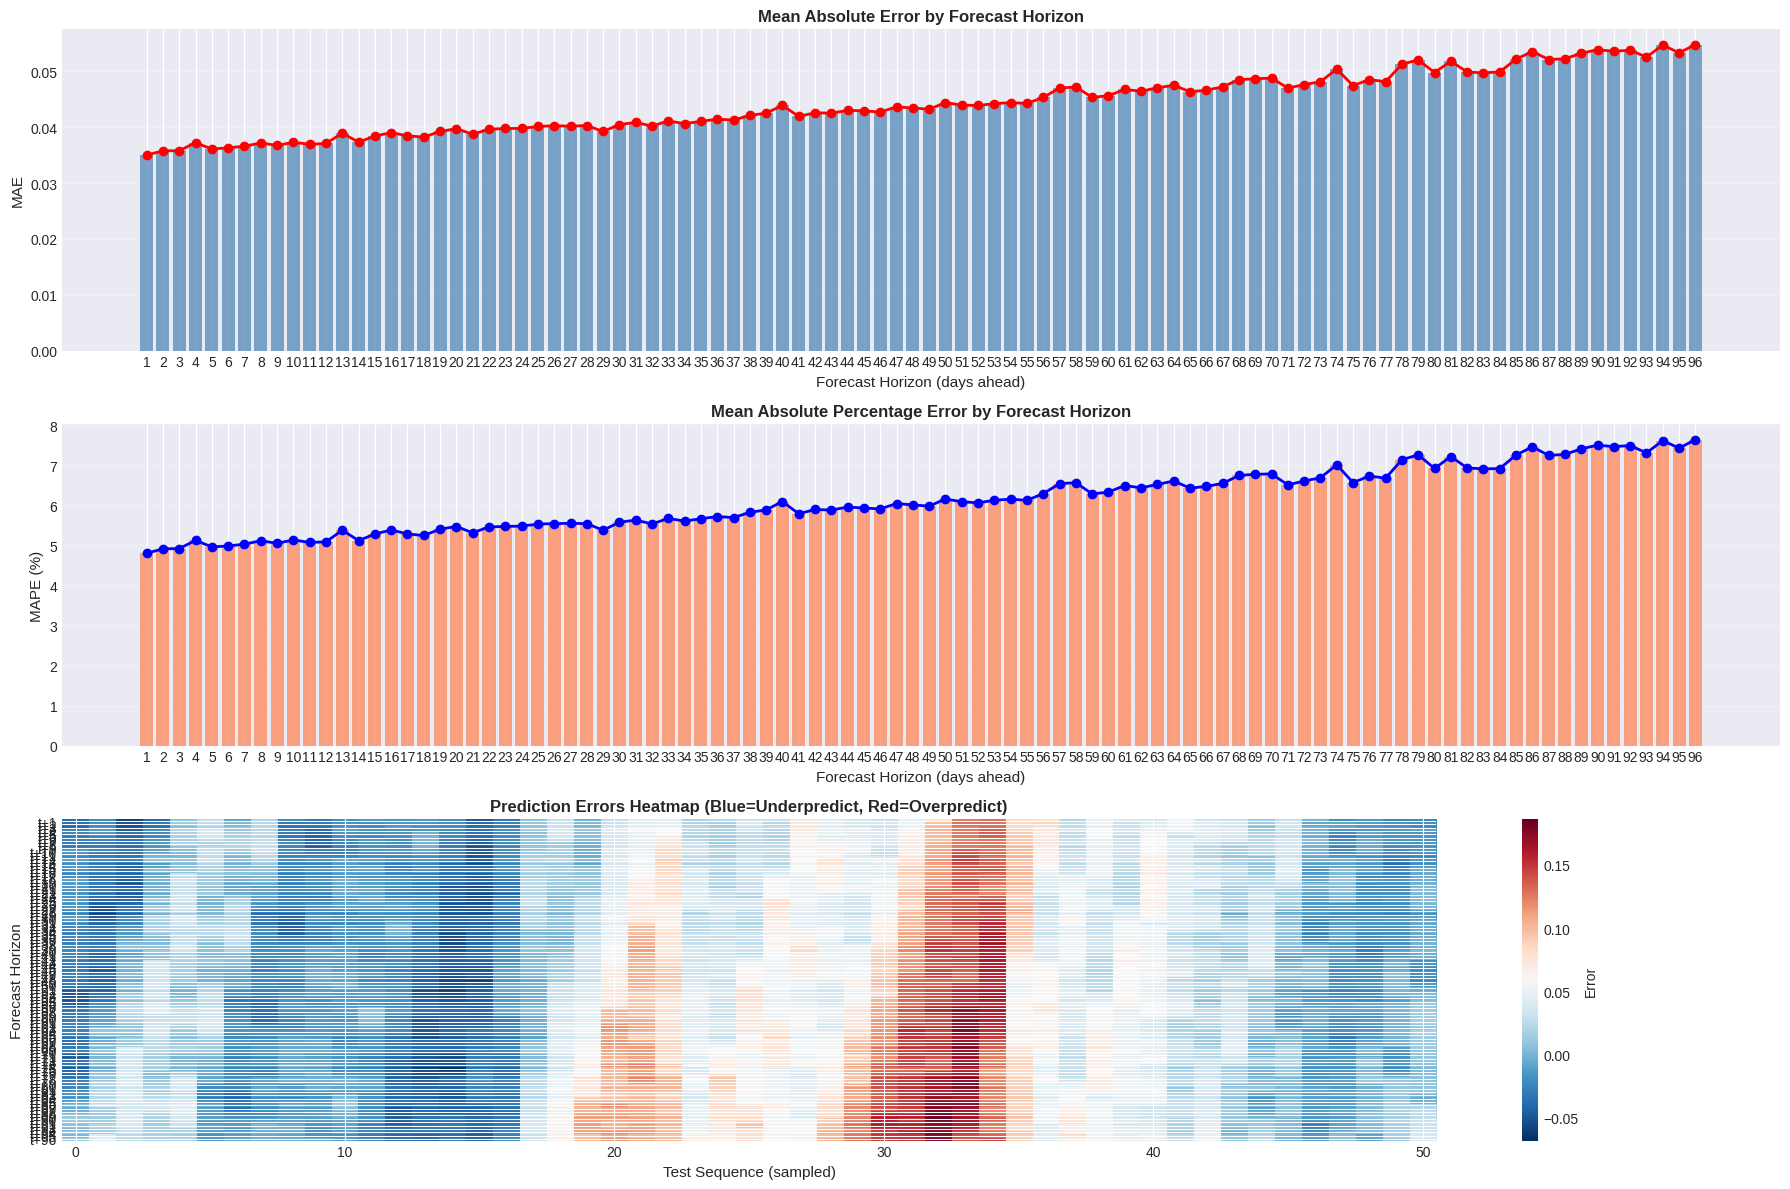

✓ Saved: multistep_analysis_column_OT.png


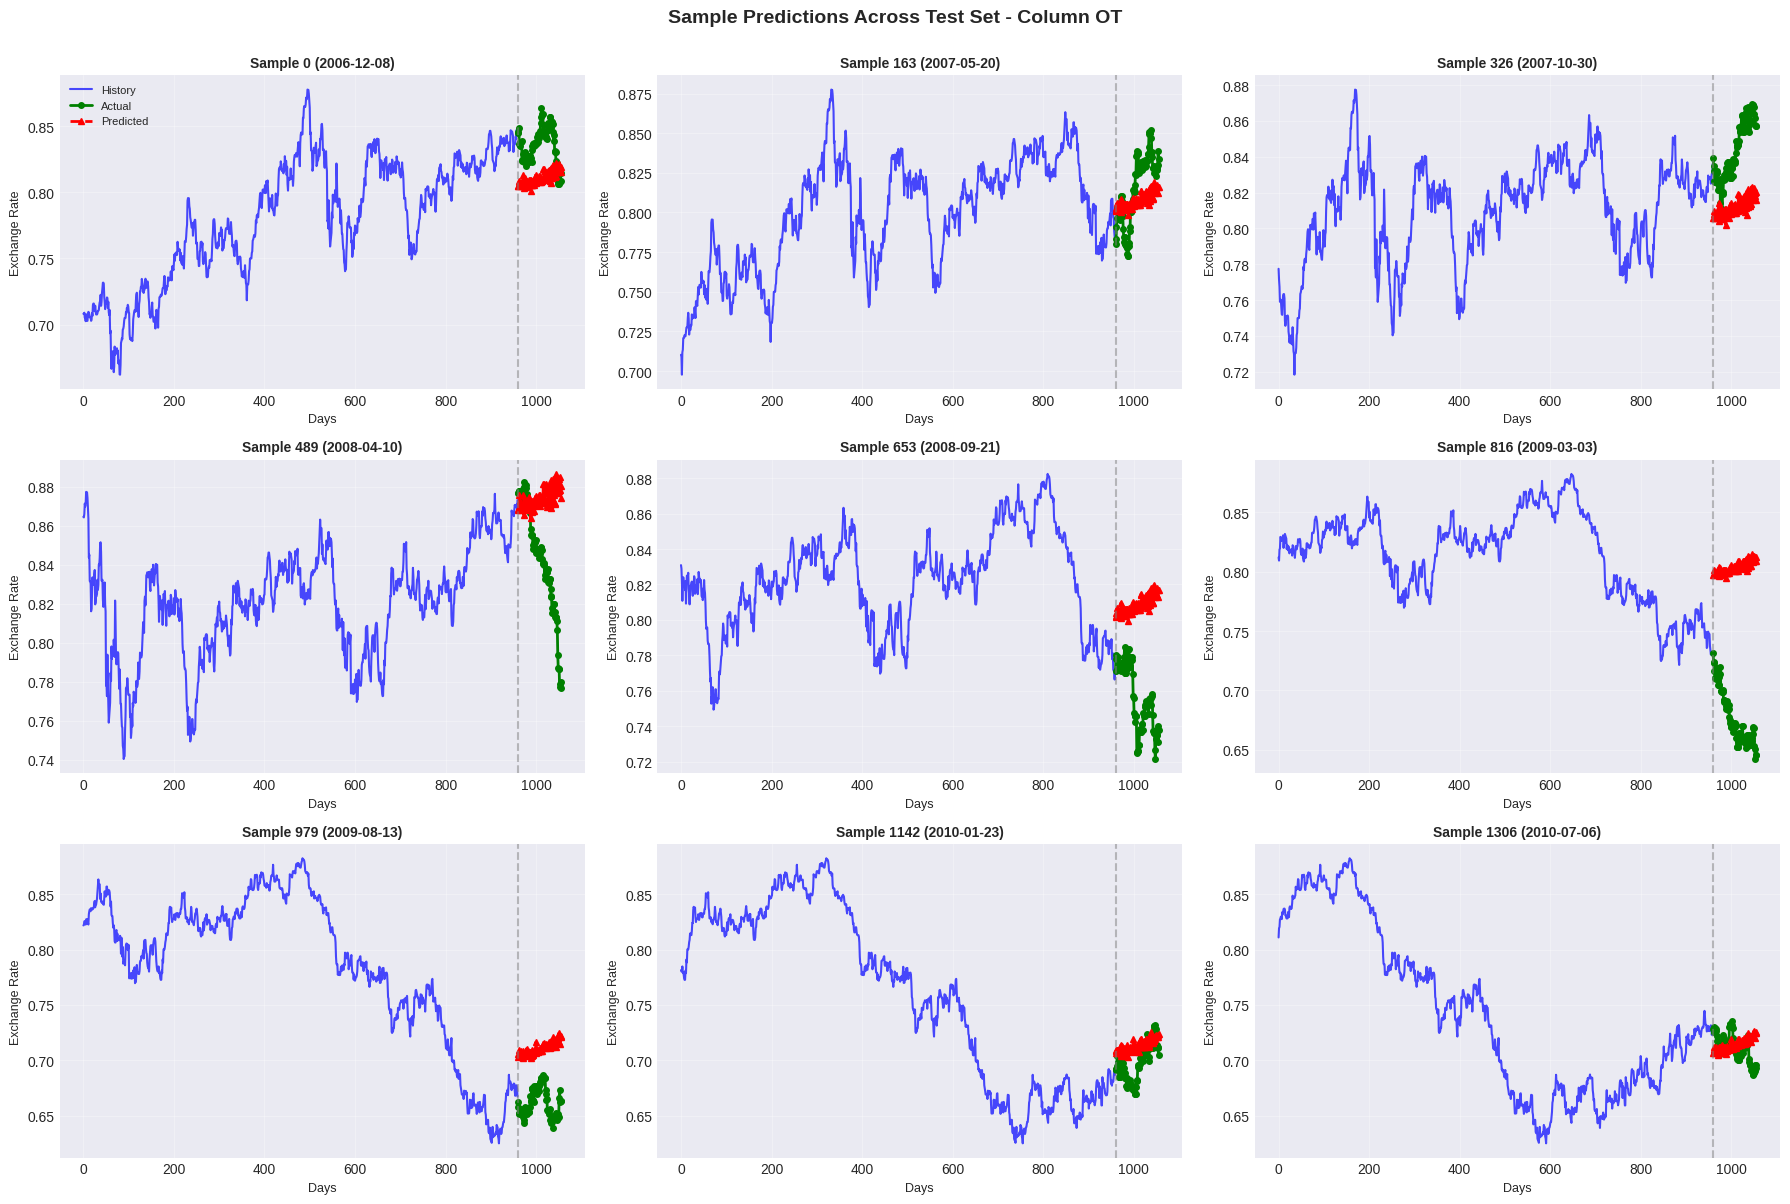

✓ Saved: sample_predictions_column_OT.png


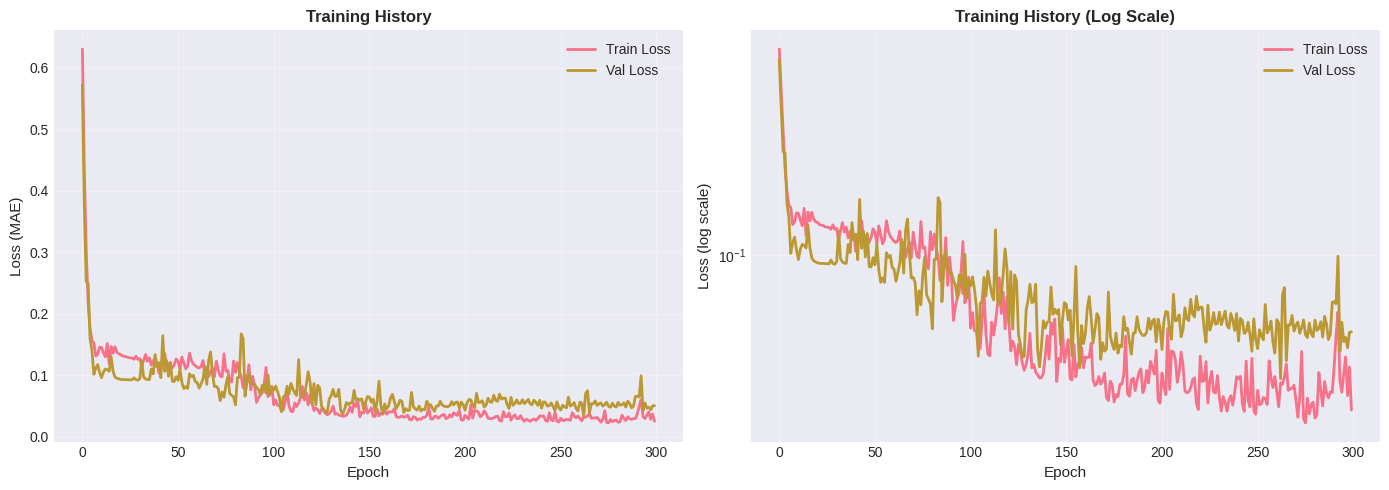

✓ Saved: training_history_column_OT.png

DETAILED METRICS BY FORECAST HORIZON
Horizon    MSE          MAE          MAPE (%)    
---------- ------------ ------------ ------------
t+1        0.001945     0.035034     4.80        
t+2        0.002031     0.035788     4.91        
t+3        0.002056     0.035808     4.92        
t+4        0.002243     0.037256     5.12        
t+5        0.002100     0.036100     4.96        
t+6        0.002128     0.036329     4.98        
t+7        0.002154     0.036607     5.03        
t+8        0.002225     0.037206     5.11        
t+9        0.002178     0.036750     5.05        
t+10       0.002273     0.037316     5.14        
t+11       0.002202     0.036960     5.07        
t+12       0.002244     0.037104     5.09        
t+13       0.002526     0.038955     5.38        
t+14       0.002248     0.037326     5.12        
t+15       0.002413     0.038441     5.28        
t+16       0.002532     0.039045     5.38        
t+17       0.002415   

/tmp/ipykernel_1256/2247756625.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[f'Actual_t+{step+1}'] = y_test_actual[:, step]
/tmp/ipykernel_1256/2247756625.py:239: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[f'Predicted_t+{step+1}'] = predictions_actual[:, step]
/tmp/ipykernel_1256/2247756625.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a


✓ Saved detailed results to: test_results_column_OT.csv

✅ ALL VISUALIZATIONS COMPLETE!

Generated files:
  1. full_test_analysis_column_OT.png - Comprehensive test set analysis
  2. multistep_analysis_column_OT.png - Multi-step forecast performance
  3. sample_predictions_column_OT.png - 9 sample predictions
  4. training_history_column_OT.png - Training curves
  5. test_results_column_OT.csv - Detailed numerical results

To test another column, change COLUMN_NAME at the top and run again!


In [4]:
# ============================================================================
# COMPREHENSIVE VISUALIZATIONS - FULL TEST SET
# ============================================================================

print("\n📊 Generating comprehensive visualizations...")

# ============================================================================
# FIGURE 1: COMPLETE TEST SET TIME SERIES
# ============================================================================
fig = plt.figure(figsize=(20, 12))

# Plot 1: Full test set - 1-step ahead predictions
ax1 = plt.subplot(3, 2, 1)
ax1.plot(test_dates, y_test_actual[:, 0], 'g-', label='Actual', linewidth=1.5, alpha=0.7)
ax1.plot(test_dates, predictions_actual[:, 0], 'r--', label='Predicted', linewidth=1.5, alpha=0.7)
ax1.fill_between(test_dates, y_test_actual[:, 0], predictions_actual[:, 0], alpha=0.2, color='purple')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Exchange Rate', fontsize=11)
ax1.set_title(f'Complete Test Set - 1-Step Ahead (t+1) - Column {COLUMN_NAME}',
             fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Multi-step forecasts (first 5 steps)
ax2 = plt.subplot(3, 2, 2)
n_steps_to_show = min(5, FORECAST_HORIZON)
for step in range(n_steps_to_show):
    ax2.plot(test_dates, y_test_actual[:, step],
            label=f'Actual t+{step+1}', alpha=0.6, linewidth=1)
    ax2.plot(test_dates, predictions_actual[:, step],
            linestyle='--', label=f'Pred t+{step+1}', alpha=0.6, linewidth=1)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Exchange Rate', fontsize=11)
ax2.set_title(f'Multi-Step Forecasts (t+1 to t+{n_steps_to_show})',
             fontsize=12, fontweight='bold')
ax2.legend(loc='best', ncol=2, fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Actual vs Predicted Scatter
ax3 = plt.subplot(3, 2, 3)
ax3.scatter(y_test_actual[:, 0], predictions_actual[:, 0], alpha=0.5, s=20, c=range(len(y_test_actual)), cmap='viridis')
min_val = min(y_test_actual[:, 0].min(), predictions_actual[:, 0].min())
max_val = max(y_test_actual[:, 0].max(), predictions_actual[:, 0].max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('Actual', fontsize=11)
ax3.set_ylabel('Predicted', fontsize=11)
ax3.set_title('Actual vs Predicted (1-step ahead)', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
# Add R² score
from sklearn.metrics import r2_score
r2 = r2_score(y_test_actual[:, 0], predictions_actual[:, 0])
ax3.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax3.transAxes,
        fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Prediction Errors Over Time
ax4 = plt.subplot(3, 2, 4)
errors = y_test_actual[:, 0] - predictions_actual[:, 0]
ax4.plot(test_dates, errors, 'purple', linewidth=1.5, alpha=0.7)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.fill_between(test_dates, 0, errors, alpha=0.3, color='purple')
ax4.set_xlabel('Date', fontsize=11)
ax4.set_ylabel('Error (Actual - Predicted)', fontsize=11)
ax4.set_title('Prediction Errors Over Time', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Plot 5: Absolute Errors Over Time
ax5 = plt.subplot(3, 2, 5)
abs_errors = np.abs(errors)
ax5.plot(test_dates, abs_errors, 'orange', linewidth=1.5, alpha=0.7)
ax5.axhline(y=np.mean(abs_errors), color='r', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(abs_errors):.6f}')
ax5.fill_between(test_dates, 0, abs_errors, alpha=0.3, color='orange')
ax5.set_xlabel('Date', fontsize=11)
ax5.set_ylabel('Absolute Error', fontsize=11)
ax5.set_title('Absolute Errors Over Time', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# Plot 6: Error Distribution
ax6 = plt.subplot(3, 2, 6)
ax6.hist(errors, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax6.axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax6.axvline(np.mean(errors), color='orange', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(errors):.6f}')
ax6.set_xlabel('Error', fontsize=11)
ax6.set_ylabel('Frequency', fontsize=11)
ax6.set_title(f'Error Distribution (μ={np.mean(errors):.6f}, σ={np.std(errors):.6f})',
             fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'full_test_analysis_column_{COLUMN_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: full_test_analysis_column_{COLUMN_NAME}.png")

# ============================================================================
# FIGURE 2: DETAILED MULTI-STEP FORECAST ANALYSIS
# ============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

# Plot 1: MAE across forecast horizons
mae_per_step = [metrics_per_step[f't+{i+1}']['MAE'] for i in range(FORECAST_HORIZON)]
axes[0].bar(range(1, FORECAST_HORIZON+1), mae_per_step, alpha=0.7, color='steelblue')
axes[0].plot(range(1, FORECAST_HORIZON+1), mae_per_step, 'r-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Forecast Horizon (days ahead)', fontsize=11)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].set_title('Mean Absolute Error by Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(1, FORECAST_HORIZON+1))

# Plot 2: MAPE across forecast horizons
mape_per_step = [metrics_per_step[f't+{i+1}']['MAPE'] for i in range(FORECAST_HORIZON)]
axes[1].bar(range(1, FORECAST_HORIZON+1), mape_per_step, alpha=0.7, color='coral')
axes[1].plot(range(1, FORECAST_HORIZON+1), mape_per_step, 'b-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Forecast Horizon (days ahead)', fontsize=11)
axes[1].set_ylabel('MAPE (%)', fontsize=11)
axes[1].set_title('Mean Absolute Percentage Error by Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(1, FORECAST_HORIZON+1))

# Plot 3: Heatmap of predictions vs actuals over time and horizon
# Sample every 10th sequence for readability
sample_indices = range(0, len(y_test_actual), max(1, len(y_test_actual)//50))
heatmap_data = predictions_actual[sample_indices, :] - y_test_actual[sample_indices, :]
im = axes[2].imshow(heatmap_data.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[2].set_xlabel('Test Sequence (sampled)', fontsize=11)
axes[2].set_ylabel('Forecast Horizon', fontsize=11)
axes[2].set_title('Prediction Errors Heatmap (Blue=Underpredict, Red=Overpredict)',
                 fontsize=12, fontweight='bold')
axes[2].set_yticks(range(FORECAST_HORIZON))
axes[2].set_yticklabels([f't+{i+1}' for i in range(FORECAST_HORIZON)])
cbar = plt.colorbar(im, ax=axes[2])
cbar.set_label('Error', fontsize=10)

plt.tight_layout()
plt.savefig(f'multistep_analysis_column_{COLUMN_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: multistep_analysis_column_{COLUMN_NAME}.png")

# ============================================================================
# FIGURE 3: SAMPLE PREDICTIONS WITH CONTEXT
# ============================================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Show 9 evenly-spaced samples across the test set
sample_indices = np.linspace(0, len(X_test)-1, 9, dtype=int)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx]

    # Get data
    history = X_test[sample_idx] * norm_constant
    actual = y_test_actual[sample_idx]
    pred = predictions_actual[sample_idx]
    sample_date = test_dates.iloc[sample_idx]

    # Plot
    ax.plot(range(LOOKBACK_PERIOD), history, 'b-', linewidth=1.5, label='History', alpha=0.7)
    ax.plot(range(LOOKBACK_PERIOD, LOOKBACK_PERIOD + FORECAST_HORIZON),
           actual, 'g-', linewidth=2, marker='o', markersize=4, label='Actual')
    ax.plot(range(LOOKBACK_PERIOD, LOOKBACK_PERIOD + FORECAST_HORIZON),
           pred, 'r--', linewidth=2, marker='^', markersize=4, label='Predicted')

    ax.axvline(LOOKBACK_PERIOD, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Sample {sample_idx} ({sample_date.date()})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Days', fontsize=9)
    ax.set_ylabel('Exchange Rate', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle(f'Sample Predictions Across Test Set - Column {COLUMN_NAME}',
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(f'sample_predictions_column_{COLUMN_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: sample_predictions_column_{COLUMN_NAME}.png")

# ============================================================================
# FIGURE 4: TRAINING CURVES
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MAE)', fontsize=11)
axes[0].set_title('Training History', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(train_losses, label='Train Loss', linewidth=2)
axes[1].semilogy(val_losses, label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss (log scale)', fontsize=11)
axes[1].set_title('Training History (Log Scale)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'training_history_column_{COLUMN_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: training_history_column_{COLUMN_NAME}.png")

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print(f"\n{'='*80}")
print("DETAILED METRICS BY FORECAST HORIZON")
print(f"{'='*80}")
print(f"{'Horizon':<10} {'MSE':<12} {'MAE':<12} {'MAPE (%)':<12}")
print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*12}")
for step in range(FORECAST_HORIZON):
    metrics = metrics_per_step[f't+{step+1}']
    print(f"t+{step+1:<8} {metrics['MSE']:<12.6f} {metrics['MAE']:<12.6f} {metrics['MAPE']:<12.2f}")
print(f"{'='*80}")

# ============================================================================
# SAVE RESULTS TO CSV
# ============================================================================
results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_t+1': y_test_actual[:, 0],
    'Predicted_t+1': predictions_actual[:, 0],
    'Error': errors,
    'Abs_Error': abs_errors
})

# Add all forecast horizons
for step in range(FORECAST_HORIZON):
    results_df[f'Actual_t+{step+1}'] = y_test_actual[:, step]
    results_df[f'Predicted_t+{step+1}'] = predictions_actual[:, step]

results_df.to_csv(f'test_results_column_{COLUMN_NAME}.csv', index=False)
print(f"\n✓ Saved detailed results to: test_results_column_{COLUMN_NAME}.csv")

print(f"\n{'='*80}")
print("✅ ALL VISUALIZATIONS COMPLETE!")
print(f"{'='*80}")
print("\nGenerated files:")
print(f"  1. full_test_analysis_column_{COLUMN_NAME}.png - Comprehensive test set analysis")
print(f"  2. multistep_analysis_column_{COLUMN_NAME}.png - Multi-step forecast performance")
print(f"  3. sample_predictions_column_{COLUMN_NAME}.png - 9 sample predictions")
print(f"  4. training_history_column_{COLUMN_NAME}.png - Training curves")
print(f"  5. test_results_column_{COLUMN_NAME}.csv - Detailed numerical results")
print(f"\nTo test another column, change COLUMN_NAME at the top and run again!")

# Modern TCN

# Informer